# 03. Exploratory Data Analysis of Ukrainian News

У цьому ноутбуці виконано EDA для доступного українськомовного корпусу TruthLens UA Analytics з акцентом на словникові відмінності між класами `FAKE` і `REAL`, а також на частотність ІПСО-патернів.

In [1]:
from pathlib import Path
from collections import Counter
import re
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.unicode_minus'] = False

CSV_PATH = Path('../data/gold/demo_cases.csv')
df = pd.read_csv(CSV_PATH)
df = df[df['expected_label'].isin(['FAKE', 'REAL'])].copy()
print(f'Для EDA використано {len(df)} україномовних кейсів.')
df[['text', 'expected_label', 'ipso']].head()

Для EDA використано 25 україномовних кейсів.


,text,expected_label,ipso
0,ТЕРМІНОВО!!! ЗСУ ЗДАЛИ Харків! Поширте до вида...,FAKE,"urgency_injection,military_disinfo,deletion_th..."
1,ПРОКИНЬТЕСЬ! Приховують правду про вакцини! По...,FAKE,"awakening_appeal,conspiracy_framing,viral_call"
2,Зеленський таємно підписав угоду з Путіним! Ан...,FAKE,"authority_impersonation,anonymous_sources"
3,ЗСУ ЗРАДНИКИ! КИНУЛИ ПОЗИЦІЇ! ПРАВДА ЯКУ ЗАМОВ...,FAKE,"military_disinfo,conspiracy_framing,caps_abuse"
4,Відео з генералом виявилось deepfake! Це AI-ві...,FAKE,deepfake_indicator


In [2]:
STOPWORDS = {
    'і','в','у','на','до','та','з','що','це','про','не','за','для','від','із','як','по','до','чи','а','але','або','при','під','над','після','перед','через','україни'
}

def tokenize(text: str):
    tokens = re.findall(r"[А-Яа-яІіЇїЄєҐґA-Za-z']+", str(text).lower())
    return [t for t in tokens if len(t) > 2 and t not in STOPWORDS]

fake_tokens = Counter()
real_tokens = Counter()
for _, row in df.iterrows():
    toks = tokenize(row['text'])
    if row['expected_label'] == 'FAKE':
        fake_tokens.update(toks)
    else:
        real_tokens.update(toks)

fake_top = pd.DataFrame(fake_tokens.most_common(10), columns=['word', 'count'])
real_top = pd.DataFrame(real_tokens.most_common(10), columns=['word', 'count'])

fake_top, real_top

(         word  count
 0   терміново      2
 1         зсу      2
 2     поширте      2
 3  приховують      2
 4      правду      2
 5       зараз      2
 6  зеленський      2
 7       відео      2
 8       здали      1
 9      харків      1,
            word  count
 0  міністерство      3
 1      верховна      2
 2          рада      2
 3       оновило      2
 4          нові      2
 5           нбу      1
 6      підвищив      1
 7      облікову      1
 8        ставку      1
 9     засіданні      1)

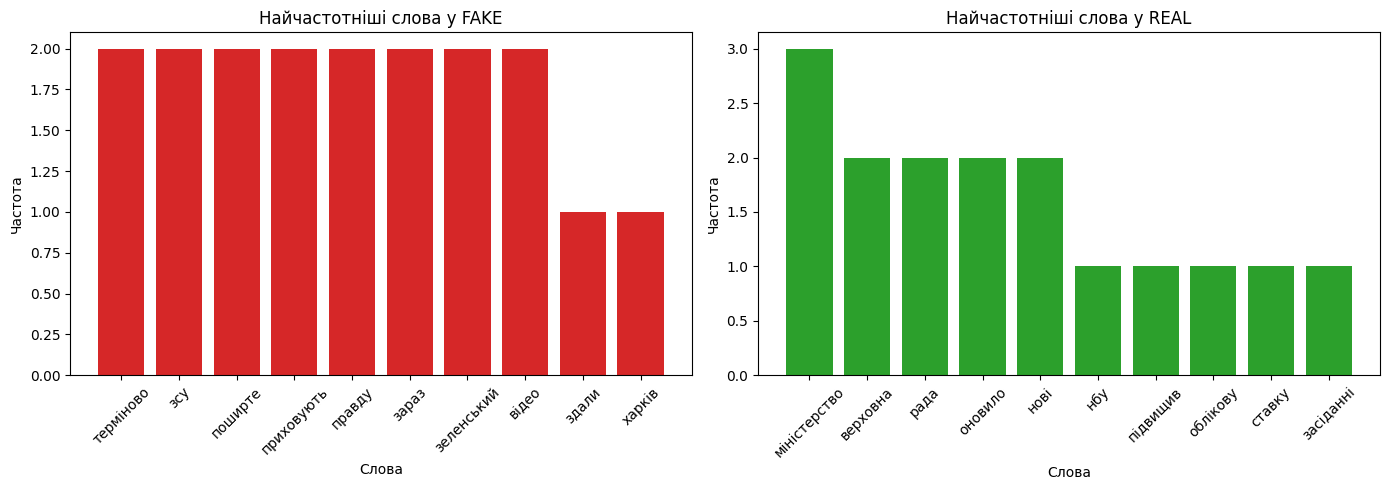

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(fake_top['word'], fake_top['count'], color='#d62728')
axes[0].set_title('Найчастотніші слова у FAKE')
axes[0].set_xlabel('Слова')
axes[0].set_ylabel('Частота')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(real_top['word'], real_top['count'], color='#2ca02c')
axes[1].set_title('Найчастотніші слова у REAL')
axes[1].set_xlabel('Слова')
axes[1].set_ylabel('Частота')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

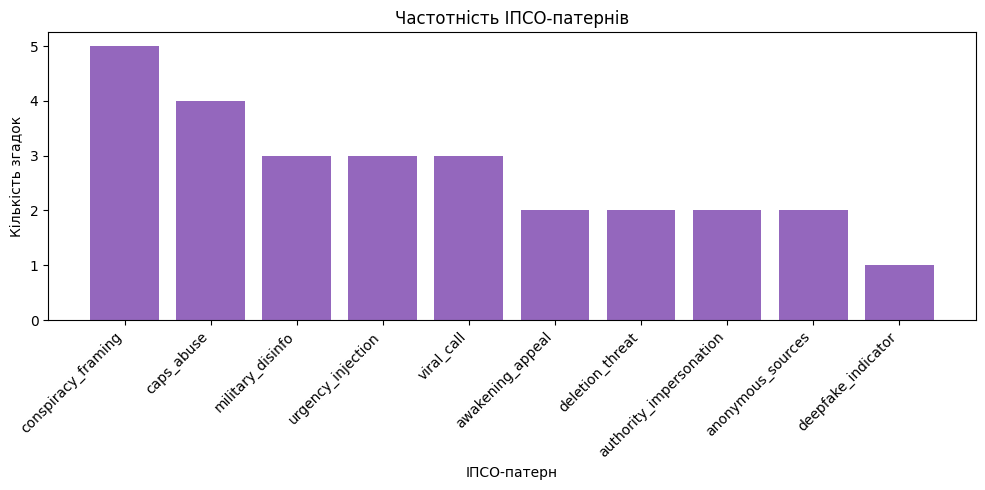

,pattern,count
0,conspiracy_framing,5
1,caps_abuse,4
2,military_disinfo,3
3,urgency_injection,3
4,viral_call,3
5,awakening_appeal,2
6,deletion_threat,2
7,authority_impersonation,2
8,anonymous_sources,2
9,deepfake_indicator,1


In [4]:
ipso_counts = (
    df.assign(ipso=df['ipso'].fillna(''))['ipso']
      .str.split(',')
      .explode()
      .str.strip()
)
ipso_counts = ipso_counts[(ipso_counts.notna()) & (ipso_counts != '')].value_counts().reset_index()
ipso_counts.columns = ['pattern', 'count']

if not ipso_counts.empty:
    plt.figure(figsize=(10, 5))
    plt.bar(ipso_counts['pattern'], ipso_counts['count'], color='#9467bd')
    plt.title('Частотність ІПСО-патернів')
    plt.xlabel('ІПСО-патерн')
    plt.ylabel('Кількість згадок')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

ipso_counts

## Висновки

Дослідницький аналіз показує, що для класу `FAKE` характерні слова терміновості, змови, анонімності та емоційного тиску, тоді як для класу `REAL` частіше трапляються інституційні, процедурні та офіційно-нейтральні формулювання. Частотність ІПСО-патернів підтверджує, що дезінформаційні кейси у вибірці тяжіють до повторюваних механізмів впливу, які можуть бути використані як додаткові евристичні ознаки в системі TruthLens UA Analytics.